#  Классификация изображений с помощью сверточных нейронных сетей

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann 
* https://pytorch.org/docs/stable/nn.html#convolution-layers
* https://pytorch.org/vision/0.16/transforms.html#v2-api-reference-recommended
* https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
* https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html
* https://kozodoi.me/blog/20210308/compute-image-stats
* https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.matshow.html

## Задачи для совместного разбора

1\. Рассмотрите основные возможности по созданию датасетов из `torchvision` и примеры работы основных слоев для создания сверточных нейронных сетей для анализа изображений.

2\. Реализуйте типовую архитектуру CNN для классификации изображений.

## Задачи для самостоятельного решения

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")


PyTorch version: 2.5.1+rocm6.2
CUDA available: True
CUDA version: None
Number of GPUs: 2
GPU 0: AMD Radeon RX 6700S
GPU 1: AMD Radeon 680M


In [4]:
torch.cuda.set_device(0)
print(f"Using device: {torch.cuda.get_device_name(torch.cuda.current_device())}")

Using device: AMD Radeon RX 6700S


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


<p class="task" id="1"></p>

1\. Создайте датасет `CatBreeds` на основе данных из архива `cat_breeds_4.zip`. Используя преобразования `torchvision`, приведите картинки к размеру 300х300 и нормализуйте значения интенсивности пикселей (рассчитайте статистику для нормализации отдельно). Выведите на экран количество картинок в датасете,  размер одной картинки, количество уникальных классов. Разбейте датасет на обучающее и тестовое множество в соотношении 80 на 20%.

- [ ] Проверено на семинаре

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from torchvision import datasets, transforms
import random
import os
from torchvision import models
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torch.distributed as dist
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
data_folder = 'cat_breeds_4'

In [7]:
size_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor()
])

In [8]:
temp_dataset = datasets.ImageFolder(root=data_folder, transform=size_transform)

FileNotFoundError: [Errno 2] No such file or directory: 'cat_breeds_4'

In [7]:
mean = torch.mean(torch.stack([image[0].mean(dim=(1, 2)) for image in temp_dataset]), dim=0)
std = torch.std(torch.stack([image[0].std(dim=(1, 2)) for image in temp_dataset]), dim=0)

In [8]:
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [9]:
cat_breeds_dataset = datasets.ImageFolder(root=data_folder, transform=transform)

In [10]:
print("Количество изображений в датасете:", len(cat_breeds_dataset))
print("Размер одного изображения:", cat_breeds_dataset[0][0].shape)
print("Количество уникальных классов:", len(cat_breeds_dataset.classes))

Количество изображений в датасете: 4000
Размер одного изображения: torch.Size([3, 300, 300])
Количество уникальных классов: 4


In [11]:
train_size = int(0.8 * len(cat_breeds_dataset))
test_size = len(cat_breeds_dataset) - train_size
train_dataset, test_dataset = random_split(cat_breeds_dataset, [train_size, test_size])

In [12]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

<p class="task" id="2"></p>

2\. Решите задачу классификации на основе датасета из предыдущего задания, не используя сверточные слои. Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве. Выведите на экран количество параметров модели.   

- [ ] Проверено на семинаре

In [33]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SimpleClassifier, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)
    
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [34]:
input_size = 300 * 300 * 3
num_classes = len(train_dataset.dataset.classes)

In [48]:
def train_model(model, criterion, optimizer, train_loader, test_loader, device, num_epochs=20):
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(100 * correct / total)
        
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        test_accuracy = 100 * correct / total
        test_accuracies.append(test_accuracy)
        
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.2f}%, Test Acc: {test_accuracy:.2f}%")

    return train_losses, train_accuracies, test_accuracies


In [51]:
model = SimpleClassifier(input_size, num_classes)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [52]:
train_losses, train_accuracies, test_accuracies = train_model(model, criterion, optimizer, train_loader, test_loader, device, num_epochs=20)

Epoch [1/20], Loss: 27.3972, Train Acc: 27.25%, Test Acc: 25.00%
Epoch [2/20], Loss: 1.4074, Train Acc: 25.31%, Test Acc: 24.25%
Epoch [3/20], Loss: 1.3735, Train Acc: 26.28%, Test Acc: 24.75%
Epoch [4/20], Loss: 1.3627, Train Acc: 27.50%, Test Acc: 31.88%
Epoch [5/20], Loss: 1.3645, Train Acc: 28.53%, Test Acc: 24.38%
Epoch [6/20], Loss: 1.3614, Train Acc: 27.19%, Test Acc: 23.88%
Epoch [7/20], Loss: 1.3550, Train Acc: 27.59%, Test Acc: 24.00%
Epoch [8/20], Loss: 1.3499, Train Acc: 27.72%, Test Acc: 23.88%
Epoch [9/20], Loss: 1.3515, Train Acc: 28.06%, Test Acc: 23.38%
Epoch [10/20], Loss: 1.3552, Train Acc: 27.38%, Test Acc: 23.88%
Epoch [11/20], Loss: 1.3518, Train Acc: 27.75%, Test Acc: 23.75%
Epoch [12/20], Loss: 1.3601, Train Acc: 27.75%, Test Acc: 23.38%
Epoch [13/20], Loss: 1.3495, Train Acc: 27.62%, Test Acc: 23.50%
Epoch [14/20], Loss: 1.3419, Train Acc: 27.88%, Test Acc: 23.25%
Epoch [15/20], Loss: 1.3505, Train Acc: 27.72%, Test Acc: 25.50%
Epoch [16/20], Loss: 1.3589, Trai

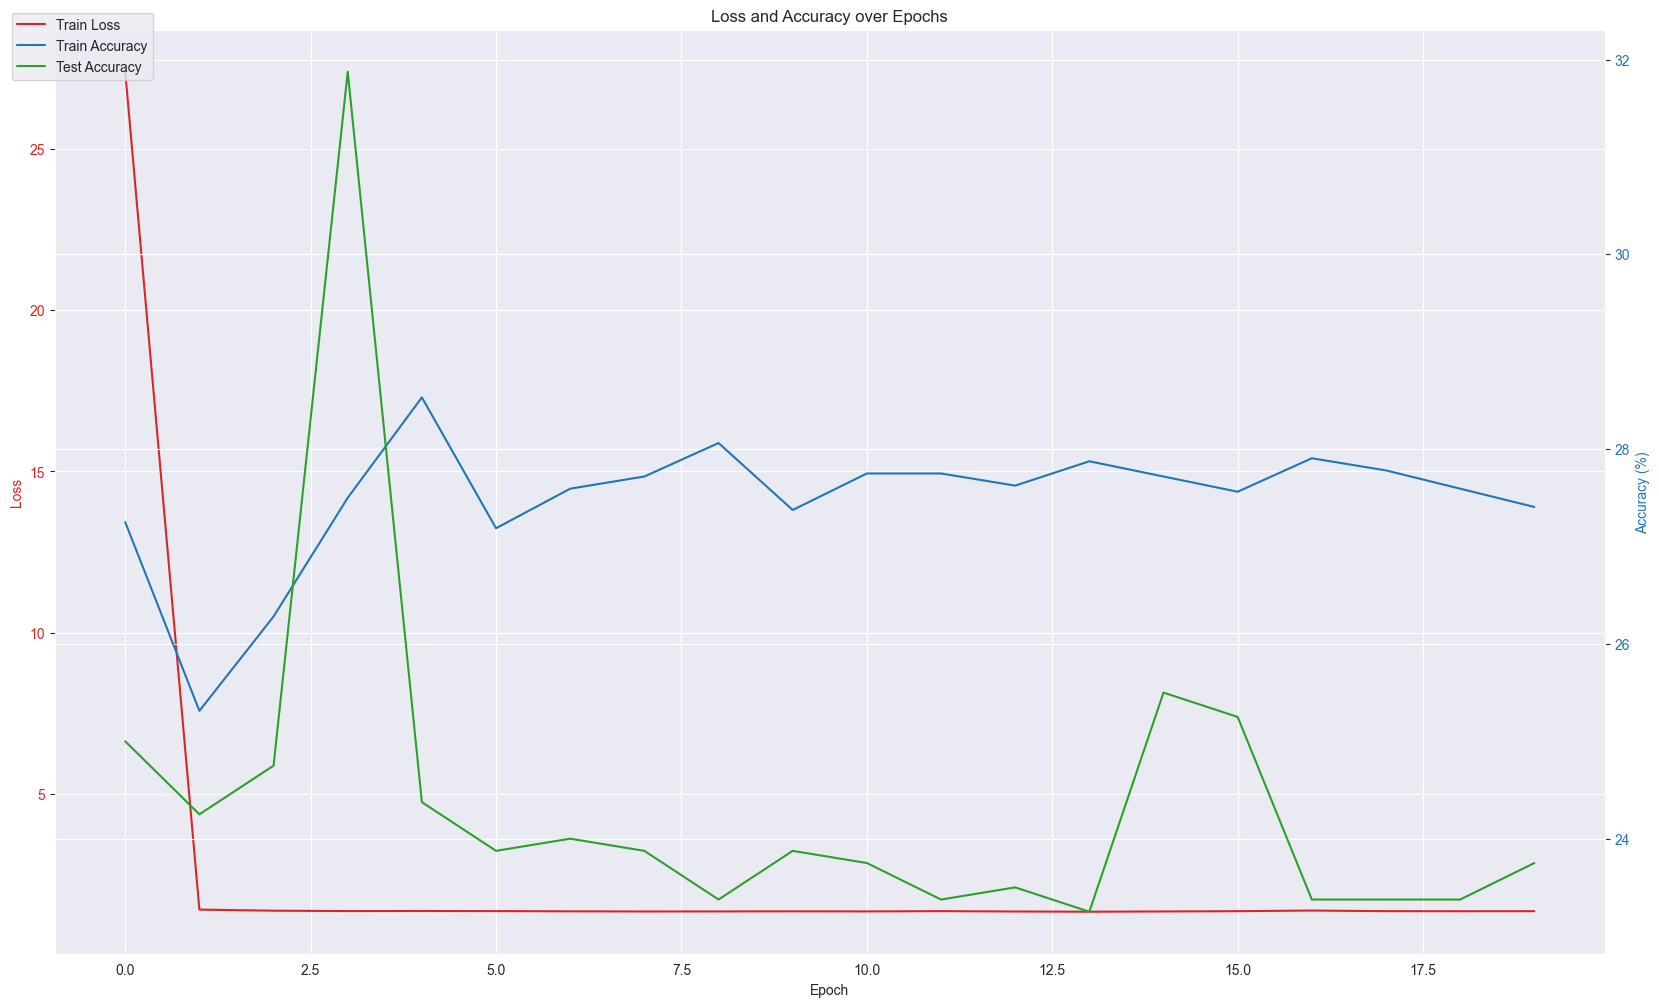

In [57]:
fig, ax1 = plt.subplots(figsize=(20, 12))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(train_losses, color='tab:red', label='Train Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy (%)', color='tab:blue')
ax2.plot(train_accuracies, color='tab:blue', label='Train Accuracy')
ax2.plot(test_accuracies, color='tab:green', label='Test Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))

plt.title('Loss and Accuracy over Epochs')
plt.show()

<p class="task" id="3"></p>

3\. Напишите функцию, которая выбирает несколько изображений из переданного набора данных и выводит их на экран в виде сетки с указанием над ними названия правильного класса и класса, предсказанного моделью. Воспользовавшись данной функцией, выведите прогнозы итоговой модели из предыдущей задачи по 6 случайным картинкам.

```
def show_examples(model, dataset, k=6):
    pass
```

- [ ] Проверено на семинаре

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


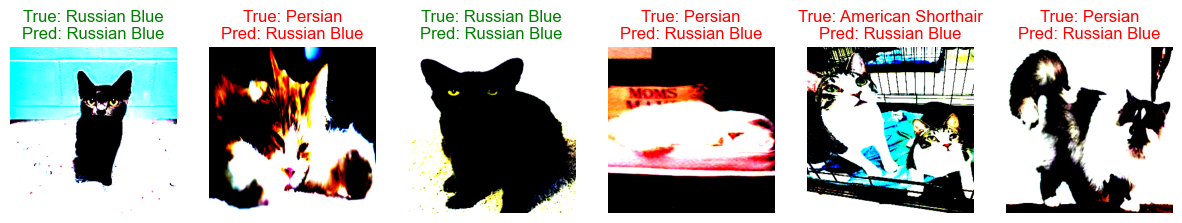

In [60]:
def show_predictions(model, test_loader, classes, device, num_images=6):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = img * 0.5 + 0.5

        axes[i].imshow(img)
        axes[i].set_title(f"True: {classes[labels[i]]}\nPred: {classes[preds[i]]}", 
                          color=("green" if labels[i] == preds[i] else "red"))
        axes[i].axis('off')

    plt.show()

show_predictions(model, test_loader, classes=test_dataset.dataset.classes, device=device, num_images=6)


<p class="task" id="4"></p>

4\. Решите задачу классификации на основе датасета из первого задания, используя сверточные слои. Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве. Выведите на экран количество параметров модели. Воспользовавшись функцией из предыдущего задания, выведите прогнозы итоговой модели по 6 случайным картинкам.

- [ ] Проверено на семинаре

In [104]:
transform_learn = transforms.Compose([
    transforms.RandomResizedCrop(300, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

transform_test = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

In [105]:
train_dataset.dataset.transform = transform_learn
test_dataset.dataset.transform = transform_test

In [106]:
import torch.nn as nn

class SimplifiedCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimplifiedCNN, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.AdaptiveAvgPool2d(1)
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


In [107]:
num_classes = len(train_dataset.dataset.classes)

In [108]:
model = CNN(num_classes=num_classes)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

In [109]:
def train_model(model, criterion, optimizer, train_loader, device, num_epochs=20):
    model.train()
    train_losses = []
    train_accuracies = []
    
    for epoch in range(num_epochs):
        train_loss = 0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(100 * correct / total)

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.2f}%")
    
    return train_losses, train_accuracies

In [110]:
def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    test_accuracies = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            test_accuracies.append(100 * correct / total)
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    
    return accuracy, test_accuracies

In [111]:
torch.cuda.empty_cache()

In [112]:
train_losses, train_accuracies = train_model(model, criterion, optimizer, train_loader, device, num_epochs=50)

Epoch [1/50], Loss: 1.3832, Train Acc: 29.16%
Epoch [2/50], Loss: 1.3302, Train Acc: 38.94%
Epoch [3/50], Loss: 1.2774, Train Acc: 43.28%
Epoch [4/50], Loss: 1.2266, Train Acc: 45.62%
Epoch [5/50], Loss: 1.1659, Train Acc: 49.62%
Epoch [6/50], Loss: 1.1570, Train Acc: 50.72%
Epoch [7/50], Loss: 1.1223, Train Acc: 52.97%
Epoch [8/50], Loss: 1.1011, Train Acc: 54.06%
Epoch [9/50], Loss: 1.0832, Train Acc: 53.81%
Epoch [10/50], Loss: 1.0366, Train Acc: 58.38%
Epoch [11/50], Loss: 1.0106, Train Acc: 58.78%
Epoch [12/50], Loss: 0.9711, Train Acc: 60.38%
Epoch [13/50], Loss: 0.9444, Train Acc: 62.75%
Epoch [14/50], Loss: 0.9128, Train Acc: 63.03%
Epoch [15/50], Loss: 0.9445, Train Acc: 61.19%
Epoch [16/50], Loss: 0.9077, Train Acc: 63.88%
Epoch [17/50], Loss: 0.8799, Train Acc: 64.53%
Epoch [18/50], Loss: 0.8329, Train Acc: 67.50%
Epoch [19/50], Loss: 0.8162, Train Acc: 67.72%
Epoch [20/50], Loss: 0.8029, Train Acc: 68.38%
Epoch [21/50], Loss: 0.7581, Train Acc: 70.50%
Epoch [22/50], Loss: 0

In [113]:
test_accuracy, test_accuracies = evaluate_model(model, test_loader, device)

Test Accuracy: 61.00%


In [114]:
test_accuracies

[60.9375, 60.9375, 60.546875, 61.0]

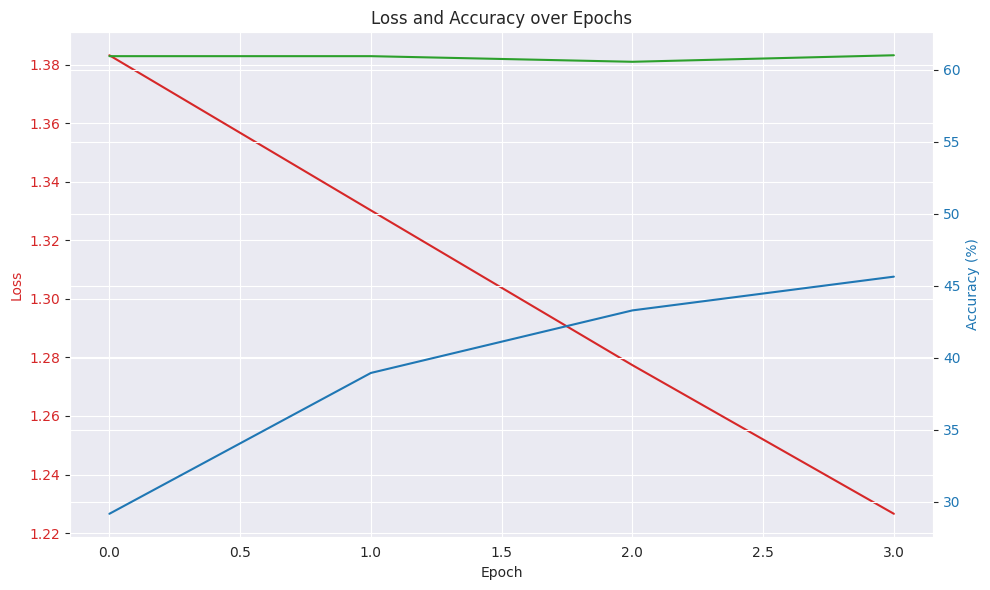

In [115]:
import numpy as np
import matplotlib.pyplot as plt

# Проверка и выравнивание длины списков
min_len = min(len(train_losses), len(train_accuracies), len(test_accuracies))

train_losses = train_losses[:min_len]
train_accuracies = train_accuracies[:min_len]
test_accuracies = test_accuracies[:min_len]

# График
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(train_losses, color='tab:red', label='Train Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy (%)', color='tab:blue')
ax2.plot(train_accuracies, color='tab:blue', label='Train Accuracy')
ax2.plot(test_accuracies, color='tab:green', label='Test Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Loss and Accuracy over Epochs')
fig.tight_layout()  # для лучшего выравнивания элементов
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.9330359..6.2293177].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.12328..6.077857].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.3515735..5.968961].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.3135242..6.2293177].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.9330359..6.2293177].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.3515735..6.2293177].


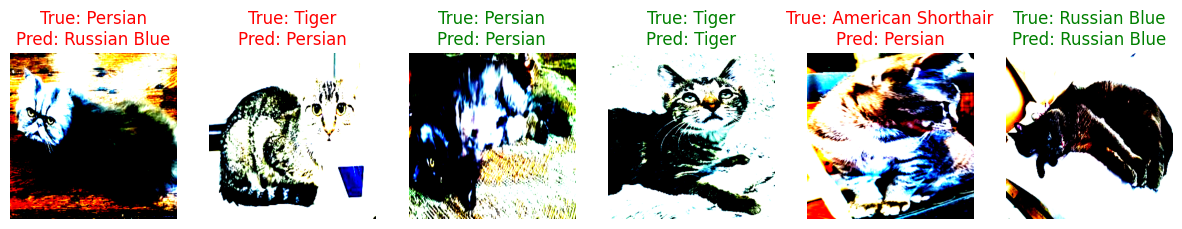

In [79]:
def show_predictions(model, test_loader, classes, device, num_images=6):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = img * 0.5 + 0.5 

        axes[i].imshow(img)
        axes[i].set_title(f"True: {classes[labels[i]]}\nPred: {classes[preds[i]]}", 
                          color=("green" if labels[i] == preds[i] else "red"))
        axes[i].axis('off')

    plt.show()

show_predictions(model, test_loader, classes=test_dataset.dataset.classes, device=device, num_images=6)


<p class="task" id="5"></p>

5\. Проанализируйте обученную в предыдущей задаче модель, исследовав обученные ядра сверточных слоев. Выберите одно изображение из тестового набора данных и пропустите через первый сверточный слой модели. Визуализируйте полученные карты признаков.

- [ ] Проверено на семинаре

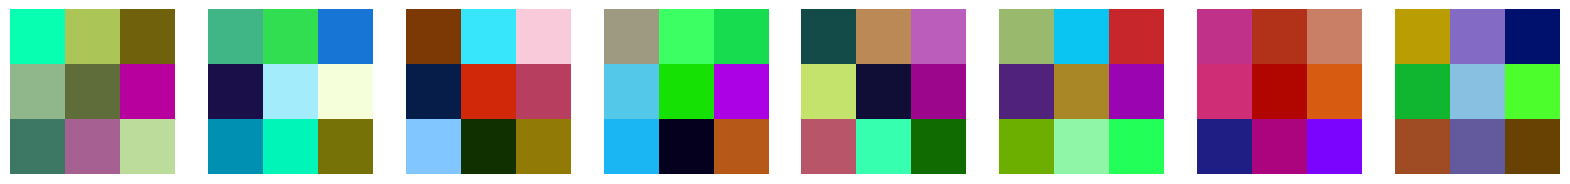

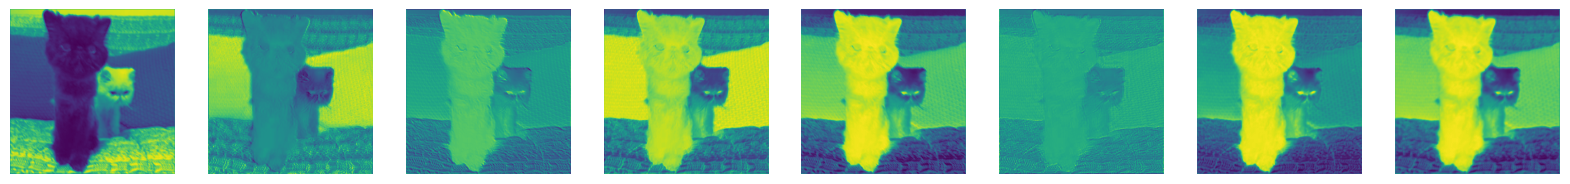

In [34]:
def visualize_filters(layer, num_filters=8):
    filters = layer.weight.data.clone().cpu()
    fig, axes = plt.subplots(1, num_filters, figsize=(20, 10))
    
    for i in range(num_filters):
        filter = filters[i]
        filter = (filter - filter.min()) / (filter.max() - filter.min())
        axes[i].imshow(filter.permute(1, 2, 0)) 
        axes[i].axis('off')
    plt.show()

visualize_filters(model.conv_layers[0], num_filters=8)

example_image, _ = test_dataset[0]
example_image = example_image.unsqueeze(0).to(device) 

with torch.no_grad():
    feature_maps = model.conv_layers[0](example_image)

def visualize_feature_maps(feature_maps, num_maps=8):
    fig, axes = plt.subplots(1, num_maps, figsize=(20, 10))
    
    for i in range(num_maps):
        fmap = feature_maps[0, i].cpu()
        axes[i].imshow(fmap, cmap='viridis')
        axes[i].axis('off')
    plt.show()

visualize_feature_maps(feature_maps, num_maps=8)

## Обратная связь
- [ ] Хочу получить обратную связь по решению